In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import scipy.optimize as opt
from numpy import pi
import cmath
from scipy.special import ellipkinc, ellipeinc

In [2]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [3]:
import os            ##  This module is for "operating system" interfaces
import sys           ##  This module is for functionality relevant to the python run time

GOOGLE_PATH_AFTER_MYDRIVE = 'Thomas Group/Code'
GOOGLE_DRIVE_PATH = os.path.join('drive','My Drive', GOOGLE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))

# Append the directory path of this notebook to what python easily "sees"
sys.path.append(GOOGLE_DRIVE_PATH)

# Make your current working directory the directory path of this notebookand data

os.chdir(GOOGLE_DRIVE_PATH)

['ZEUS_shot.ipynb', '__pycache__', 'q3d_laser.ipynb', 'field_reconstruction_modfied.py', 'q3d_PWPA_diagnostics.ipynb', 'dephasingless_pwpa_plasma_profile.py', 'APWaves.ipynb', 'Paper Sim Parameters.gsheet', 'dePWPAnProfile.ipynb']


In [5]:
import dephasingless_pwpa_plasma_profile as depa

In [111]:
nc0_np0 = 25.0
kp0Ld0 = 1
nd0_np0 = 0.9
lambda_L0 = 8.e-7
kp0z_final = 50000
n_steps = 2000

kp0z, n_n0_depa, k_kp0_depa_sq = depa.get_pwpa_profile(nc0_np0, nd0_np0, kp0Ld0, kp0z_final = 200000, n_steps = 2000)
gamma_m, _, _, _ = depa.v_gamma(nd0_np0, kp0Ld0, n_n0_depa)
k_kp0_depa = np.sqrt(k_kp0_depa_sq)
zeta_delta = depa.get_tau_where_delta_n_is_0(nd0_np0, kp0Ld0, n_n0_depa)

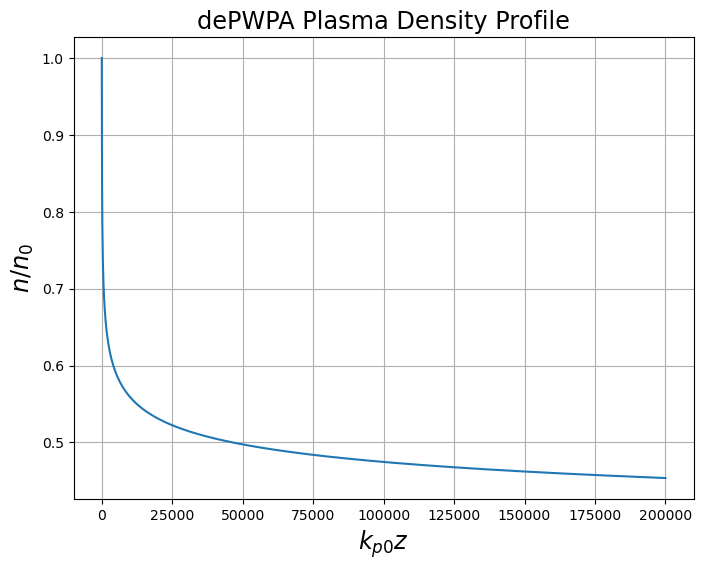

In [112]:
plt.figure(figsize = (8, 6))
plt.plot(kp0z, n_n0_depa)
plt.title('dePWPA Plasma Density Profile', fontsize = 'xx-large')
plt.xlabel('$k_{p0}z$', fontsize = 'xx-large')
plt.ylabel('$n/n_0$', fontsize = 'xx-large')
plt.grid()

58.728749148685836


Text(0.5, 0, '$k_{p0}z$')

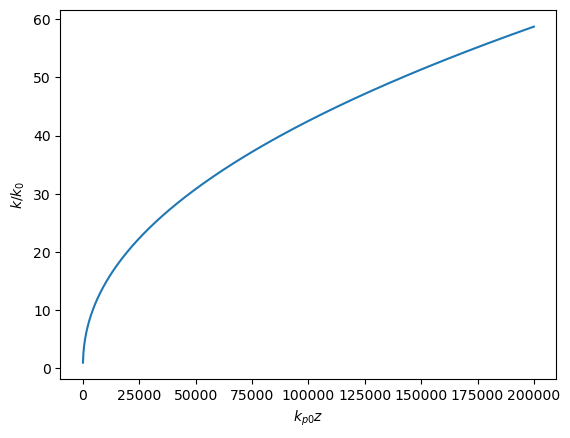

In [113]:
plt.plot(kp0z, k_kp0_depa/k_kp0_depa[0])
print(k_kp0_depa[-1]/k_kp0_depa[0])
plt.ylabel(r'$k/k_0$')
plt.xlabel(r'$k_{p0}z$')

In [114]:
def model_func(x, *params) :
  return params[0] + params[1]/(params[2] + x)**(params[3])

params, cov = opt.curve_fit(model_func, kp0z, n_n0_depa, p0 = [  0.243753, 1.056018, 7.366167, 0.166153])
print(f"{params[0]:f}, {params[1]:f}, {params[2]:f}, {params[3]:f}")

0.253346, 1.123593, 17.965020, 0.141189


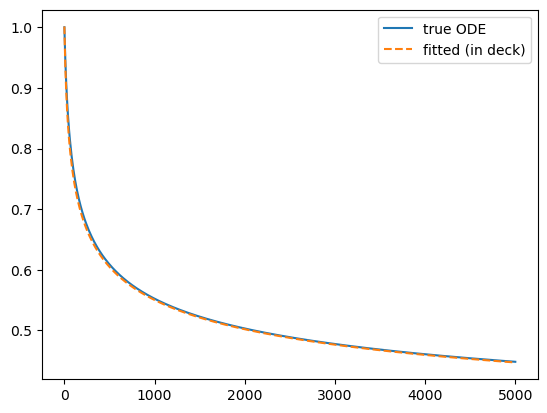

In [109]:
z_check = np.linspace(0, 5000, 500)
kp0z_full, n_n0_full, _ = depa.get_pwpa_profile(25.93, 0.6, 1.0, kp0z_final=5000, n_steps=5000)
n_ode = np.interp(z_check, kp0z_full, n_n0_full)
n_fit = 0.175114 + 1.515548/(20.304720 + z_check)**0.201521
plt.plot(z_check, n_ode, label='true ODE')
plt.plot(z_check, n_fit, '--', label='fitted (in deck)')
plt.legend()

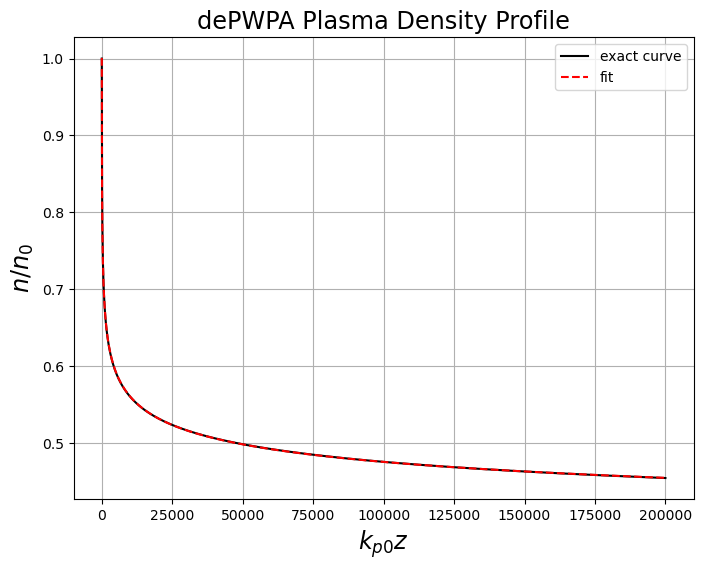

In [110]:
fit = model_func(kp0z, *params)

plt.figure(figsize = (8, 6))
plt.plot(kp0z, n_n0_depa, color = 'black', label = 'exact curve')
plt.plot(kp0z, fit, color = 'red', linestyle = 'dashed', label = 'fit')
plt.title('dePWPA Plasma Density Profile', fontsize = 'xx-large')
plt.xlabel('$k_{p0}z$', fontsize = 'xx-large')
plt.ylabel('$n/n_0$', fontsize = 'xx-large')
plt.legend()
plt.grid()


In [71]:
n_d = nd0_np0
n_p = n_n0_depa

kp = np.sqrt(n_p)
gamma_max,gamma_drive_end,p_drive_end,E_drive_end = depa.v_gamma(nd0_np0,kp0Ld0,n_p)
q = -1
qE_drive_end_kp = E_drive_end / kp
beta_drive_end = p_drive_end / gamma_drive_end
nb = n_p / (1-beta_drive_end)
phi_wake = np.arctan2(qE_drive_end_kp * np.sqrt(1+gamma_drive_end), p_drive_end*np.sqrt(2))
phi_wake_unwrap = np.unwrap(phi_wake * 2) / 2
phi_wake_pi = phi_wake_unwrap / np.pi
next_int = np.ceil(phi_wake_pi)
next_odd_int = next_int + np.mod(next_int + 1,2)
phi_dn0 = np.pi * (next_odd_int + 0.5)
kappa = np.sqrt((gamma_m-1)/(gamma_m+1))
kappap = np.sqrt(2/(gamma_m+1))

In [72]:
dump = 0
phi = np.linspace(-np.pi, 5*np.pi/2, 100)
zeta = (2/kappap[dump]*ellipeinc(phi, kappa[dump]**2) - kappap[dump]*ellipkinc(phi, kappa[dump]**2) - 2*kappa[dump]/kappap[dump]*np.sin(phi))/np.sqrt(n_n0_depa[dump]) - (2/kappap[dump]*ellipeinc(phi_wake_unwrap[dump], kappa[dump]**2) - kappap[dump]*ellipkinc(phi_wake_unwrap[dump], kappa[dump]**2) - 2*kappa[dump]/kappap[dump]*np.sin(phi_wake_unwrap[dump]))/np.sqrt(n_n0_depa[dump]) + kp0Ld0
gamma = gamma_m[dump] - (gamma_m[dump]-1)*np.sin(phi)**2
p = np.sqrt((gamma_m[dump]-1)*(gamma+1))*np.cos(phi)
beta = p/gamma
n = n_n0_depa[dump]/(1-beta)

4.992389073283723 1


Text(0.5, 0, '$\\omega_{p0}\\zeta$')

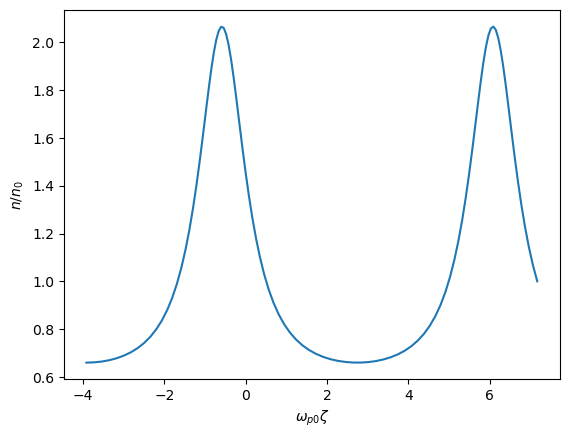

In [73]:
plt.plot(zeta, n)
#plt.axvline(kp0Ld0)
#plt.axvline(zeta_delta[dump])
print(zeta_delta[dump], kp0Ld0)
plt.ylabel(r'$n/n_0$')
plt.xlabel(r'$\omega_{p0}\zeta$')

4.992389073283723 1


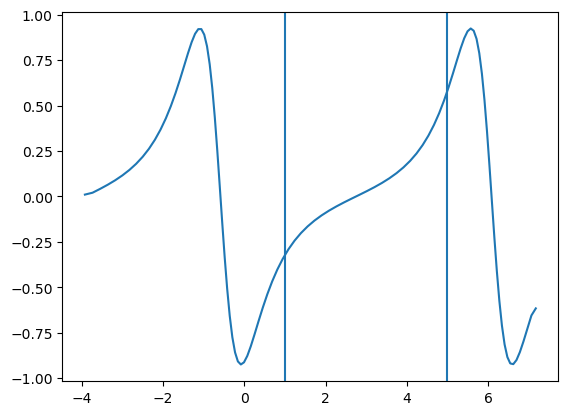

In [74]:
plt.plot(zeta, np.gradient(n/gamma, zeta))
plt.axvline(kp0Ld0)
plt.axvline(zeta_delta[dump])
print(zeta_delta[dump], kp0Ld0)